In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE

print("All imports successful ✅")

All imports successful ✅


In [2]:
df = pd.read_csv('../data/creditcard.csv')

print(f"Dataset shape  : {df.shape}")
print(f"Fraud cases    : {df['Class'].sum():,}")
print(f"Legit cases    : {(df['Class']==0).sum():,}")
print(f"Fraud rate     : {df['Class'].mean()*100:.4f}%")

Dataset shape  : (284807, 31)
Fraud cases    : 492
Legit cases    : 284,315
Fraud rate     : 0.1727%


In [3]:
# X = everything the model uses to learn (features)
# y = what we're trying to predict (0=legit, 1=fraud)

X = df.drop(columns=['Class'])
y = df['Class']

print(f"Features (X) shape : {X.shape}")
print(f"Target (y) shape   : {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")

Features (X) shape : (284807, 30)
Target (y) shape   : (284807,)

Feature columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [4]:
scaler = StandardScaler()

# Scale Amount and Time
# (V1-V28 are already scaled from PCA processing)
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time']   = scaler.fit_transform(X[['Time']])

print("Scaling done ✅")
print(f"\nAmount stats after scaling:")
print(X['Amount'].describe().round(4))

Scaling done ✅

Amount stats after scaling:
count    284807.0000
mean         -0.0000
std           1.0000
min          -0.3532
25%          -0.3308
50%          -0.2653
75%          -0.0447
max         102.3622
Name: Amount, dtype: float64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% training, 20% testing
    random_state=42,      # so results are reproducible
    stratify=y            # maintain fraud ratio in both splits
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"\nFraud in train : {y_train.sum():,}")
print(f"Fraud in test  : {y_test.sum():,}")

Training set   : 227,845 rows
Test set       : 56,962 rows

Fraud in train : 394
Fraud in test  : 98


In [6]:
print("Before SMOTE:")
print(f"  Legit in train : {(y_train==0).sum():,}")
print(f"  Fraud in train : {(y_train==1).sum():,}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Legit in train : {(y_train_balanced==0).sum():,}")
print(f"  Fraud in train : {(y_train_balanced==1).sum():,}")
print(f"\nTotal training samples: {len(X_train_balanced):,}")

Before SMOTE:
  Legit in train : 227,451
  Fraud in train : 394

After SMOTE:
  Legit in train : 227,451
  Fraud in train : 227,451

Total training samples: 454,902


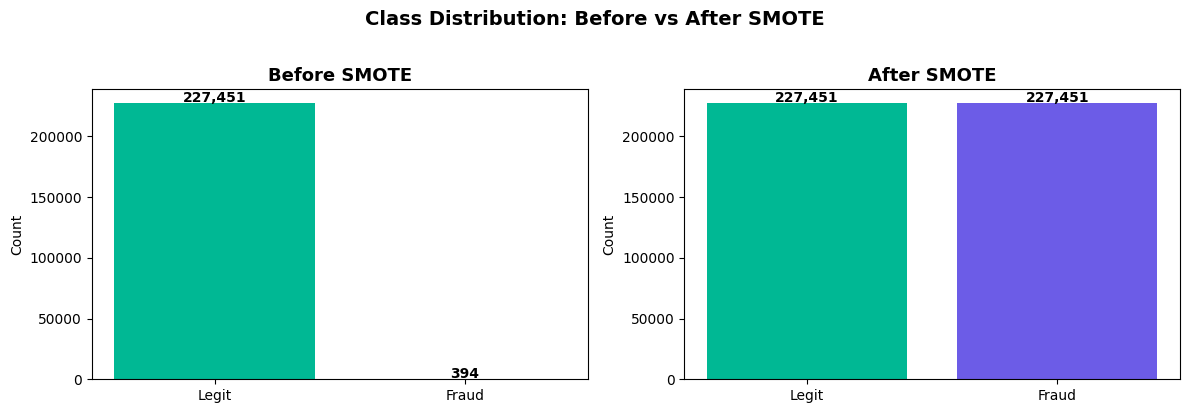

SMOTE chart saved ✅


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
before_counts = y_train.value_counts()
axes[0].bar(['Legit', 'Fraud'], before_counts.values,
            color=['#00B894', '#E17055'])
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# After SMOTE
after_counts = pd.Series(y_train_balanced).value_counts()
axes[1].bar(['Legit', 'Fraud'], after_counts.values,
            color=['#00B894', '#6C5CE7'])
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After SMOTE',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/smote_comparison.png', dpi=150)
plt.show()
print("SMOTE chart saved ✅")

In [8]:
print("Training Random Forest... (takes 1-2 minutes)")

model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=10,          # each tree can ask max 10 questions
    class_weight='balanced', # extra penalty for missing fraud
    random_state=42,
    n_jobs=-1              # use all CPU cores to speed up
)

model.fit(X_train_balanced, y_train_balanced)
print("Model trained ✅")


Training Random Forest... (takes 1-2 minutes)
Model trained ✅


In [9]:
# Make predictions on test data (data model has never seen)
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Print full report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Legit', 'Fraud']))

# ROC-AUC Score
auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score : {auc:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.43      0.88      0.58        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score : 0.9836


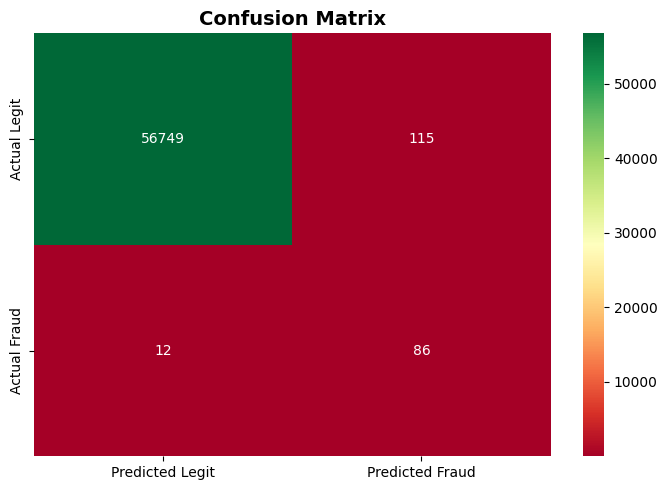


True Negatives  (correctly caught legit) : 56,749
False Positives (legit flagged as fraud)  : 115
False Negatives (fraud we MISSED)         : 12
True Positives  (fraud correctly caught)  : 86

Fraud Recall : 87.76% of frauds caught


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='RdYlGn',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly caught legit) : {tn:,}")
print(f"False Positives (legit flagged as fraud)  : {fp:,}")
print(f"False Negatives (fraud we MISSED)         : {fn:,}")
print(f"True Positives  (fraud correctly caught)  : {tp:,}")
print(f"\nFraud Recall : {tp/(tp+fn)*100:.2f}% of frauds caught")

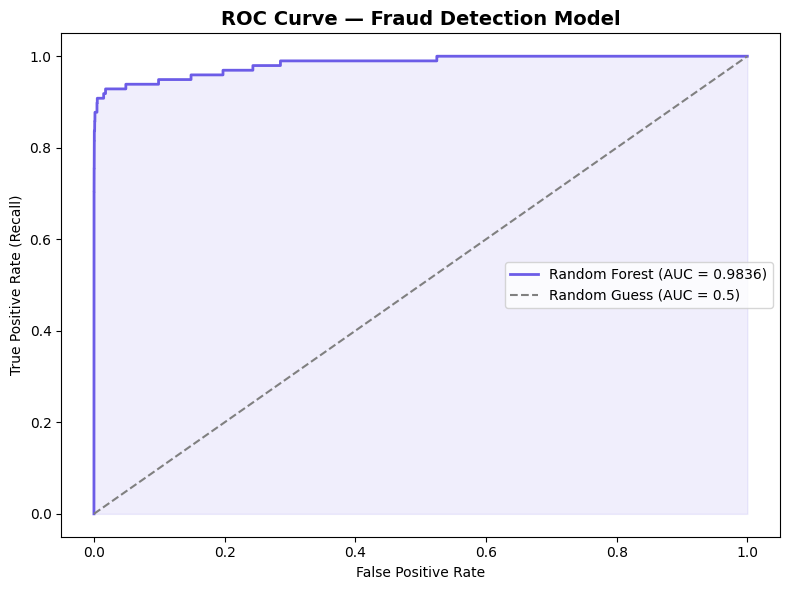

ROC curve saved ✅


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#6C5CE7', linewidth=2,
         label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--',
         label='Random Guess (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#6C5CE7')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Fraud Detection Model',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/roc_curve.png', dpi=150)
plt.show()
print("ROC curve saved ✅")

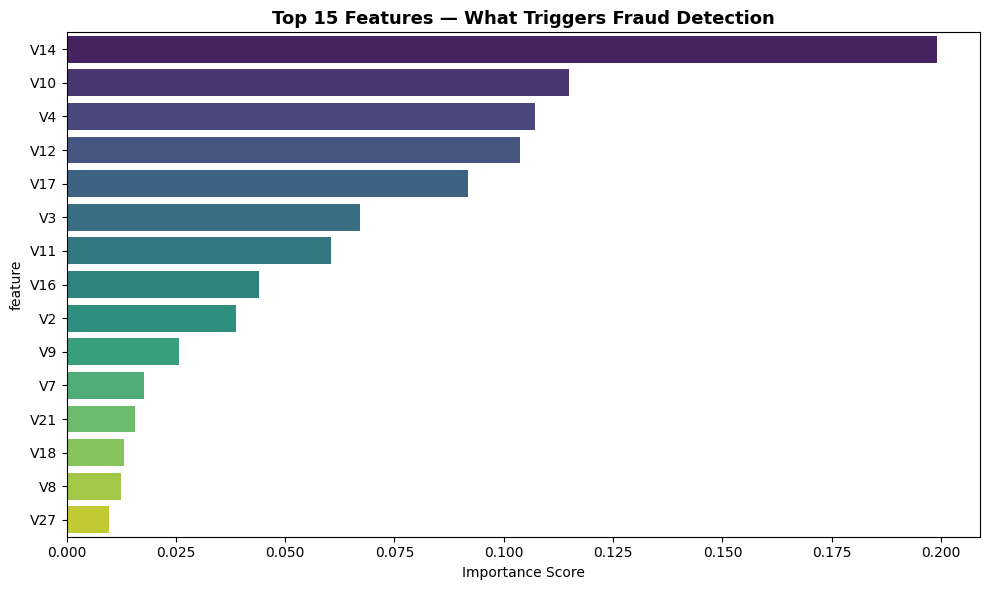

Feature importance chart saved ✅


In [12]:
feature_importance = pd.DataFrame({
    'feature'   : X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance,
            x='importance', y='feature',
            palette='viridis')
plt.title('Top 15 Features — What Triggers Fraud Detection',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart saved ✅")

In [13]:
# Save model and scaler so we can reuse them
# without retraining every time
os.makedirs('../models', exist_ok=True)
joblib.dump(model,  '../models/fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("fraud_model.pkl saved ✅")
print("scaler.pkl saved ✅")
print(f"\nModel file size: {os.path.getsize('../models/fraud_model.pkl')/1024/1024:.1f} MB")

fraud_model.pkl saved ✅
scaler.pkl saved ✅

Model file size: 3.8 MB
